In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import Neurons


## Load Iris Data

In [4]:
df = pd.read_csv('/Users/jared.mcbride/Documents/Code Projects/python-machine-learning-book-3rd-edition/ch02/iris.data', header=None)

df.value_counts(df.columns[4])

# dicard virginica
df = df.iloc[0:100,:]
df.shape

# Sample all (shuffle)
df = df.sample(frac=1)

# Extract targets
Y = df.iloc[:,4].values
Y = np.where(Y == 'Iris-setosa', -1, 1) # where(condition, if ture, if false)
Y

# Design matrix
X = df.iloc[:,[0,2]].values
X

X_train = X[0:80,:]
Y_train = Y[0:80]
X_test = X[80:100,:]
Y_test = Y[80:100]
Y_test

array([-1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1, -1, -1, -1,
       -1, -1,  1])

Weights:  [-0.38375655 -0.92611756  1.85471828]
Error rate:  0.0


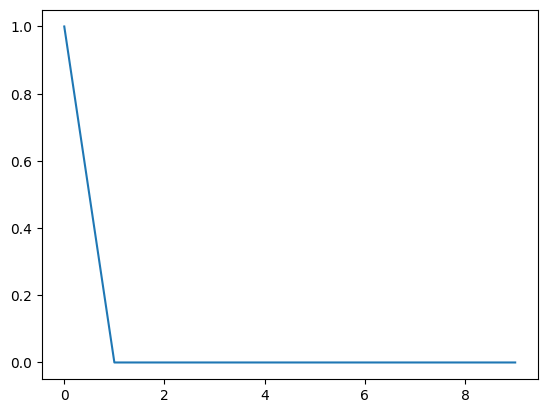

In [9]:
Perc = Neurons.Perceptron(eta=0.1, n_epochs=10)
Perc.fit(X_train, Y_train)

print("Weights: ", Perc.w_)

Y_pred = [Perc.predict(xi) for xi in X_test]
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Perc.errors_)

Weights:  [-0.06861224 -0.22326885  0.4814903 ]
Error rate:  0.0


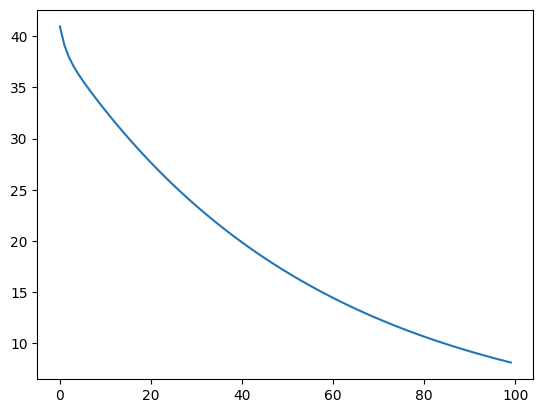

In [11]:
Ada = Neurons.Adaline(eta=0.0001, n_epochs=100)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Ada.cost_)

Weights:  [-0.360522   -0.36306156  0.76467865]
Error rate:  0.0


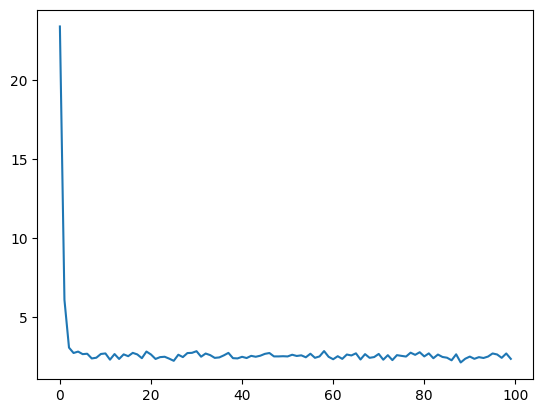

In [12]:
Ada = Neurons.AdalineSGD(eta=0.01, n_epochs=100)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Ada.cost_)

Weights:  [-0.15623576 -0.39393986  0.79600694]
Error rate:  0.0


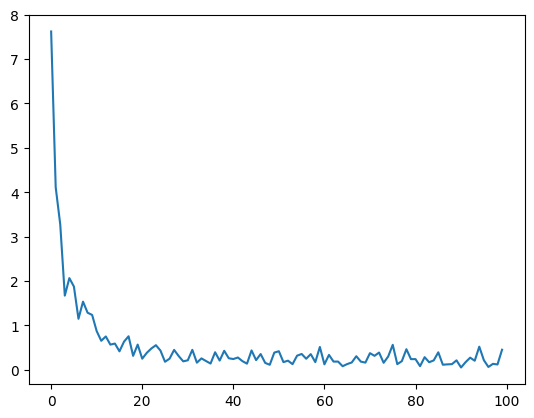

In [13]:
Ada = Neurons.AdalineMBGD(eta=0.001, n_epochs=100)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Ada.cost_)

Weights:  [-0.28818023 -0.80377594  1.73038363]
Error rate:  0.0


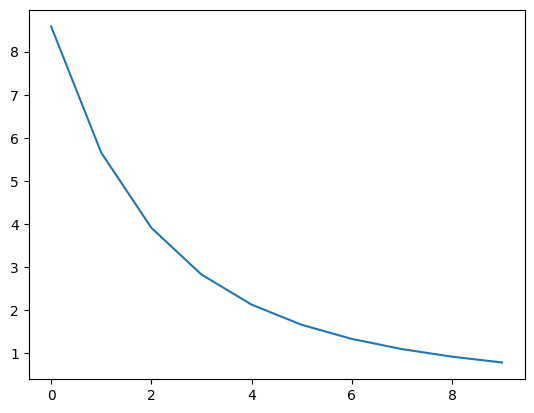

In [14]:
Y_t = np.where(Y == -1, 0, 1)

PM = Neurons.PerceptronMcKay(eta=0.01, n_epochs=10)
PM.fit(X_train, Y_t)

print("Weights: ", PM.w_)


Y_pred = [np.where(PM.predict(xi) >= .5, 1, -1) for xi in X_test]
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(PM.errors_)

## Load Women's Basket Ball data

In [15]:
dfbb = pd.read_csv('WBB.csv')

drop_indices = [i for i in dfbb.index if sum(dfbb.iloc[i,:-1]) == 0.0]
dfbb = dfbb.drop(index=drop_indices)

dfbb = dfbb.sample(frac=1)

Y = dfbb.pop('team').values
Y = np.where(Y == 0, -1, 1)

X = dfbb.values

X_train = X[0:50,:]
Y_train = Y[0:50]
X_test = X[50:100,:]
Y_test = Y[50:100]
Y_test

array([-1,  1,  1, -1, -1, -1, -1,  1, -1,  1, -1, -1])

Weights:  [-1.43756546e-01 -6.28611756e+00 -2.94528172e+00  6.22927031e+00
  7.78865408e+00  1.95169846e+01 -5.02255188e+00 -1.31676121e+01
  1.66431904e+01  3.03750630e+00  9.11462108e+00 -6.01407095e-04
  6.95677583e+00  4.39615946e+00 -1.92866231e+00  2.96900109e+00
  4.58275718e-01]
Error rate:  0.08333333333333333


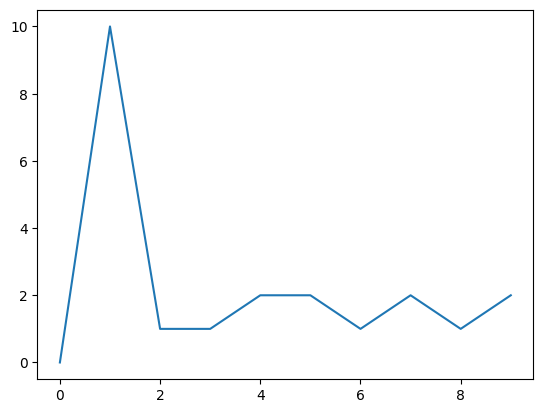

In [17]:
Perc = Neurons.Perceptron(eta=0.01, n_epochs=10)
Perc.fit(X_train, Y_train)

print("Weights: ", Perc.w_)

Y_pred = [Perc.predict(xi) for xi in X_test]
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Perc.errors_)

Weights:  [ 0.01627581 -0.00859127  0.00614182 -0.01355385  0.00842151 -0.01143322
  0.01902098 -0.01805531  0.0173653   0.01098672  0.01870703 -0.02192306
  0.00931297 -0.00666157  0.00875943 -0.00205327 -0.00134048]
Error rate:  0.08333333333333333


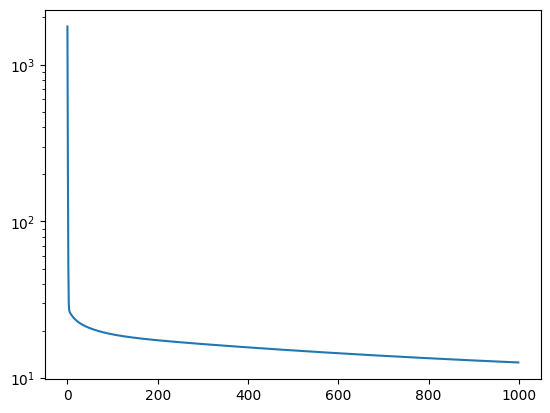

In [23]:
Ada = Neurons.Adaline(eta=0.000_000_1, n_epochs=1000)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.semilogy(Ada.cost_)

Weights:  [ 0.0162756  -0.00856807  0.00621885 -0.01359955  0.00835081 -0.01139415
  0.01903709 -0.01807257  0.01741353  0.01105623  0.01862448 -0.02191866
  0.00932145 -0.00670505  0.00875711 -0.00204975 -0.00134097]
Error rate:  0.08333333333333333


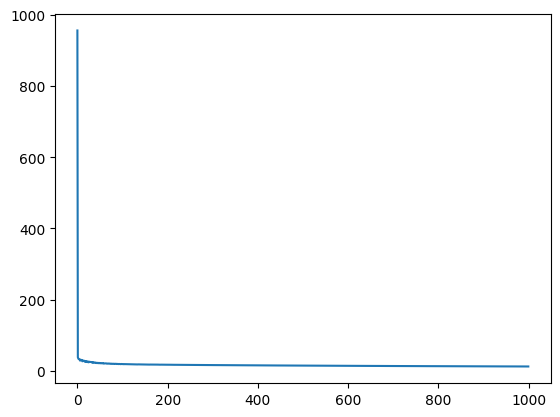

In [27]:
Ada = Neurons.AdalineSGD(eta=0.000_000_1, n_epochs=1000)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Ada.cost_)

Weights:  [ 0.01627574 -0.00857025  0.00621003 -0.01359305  0.00836185 -0.01140212
  0.01903571 -0.01806614  0.01740388  0.01104848  0.01863942 -0.02191911
  0.00932068 -0.00670005  0.00875803 -0.00204906 -0.001341  ]
Error rate:  0.08333333333333333


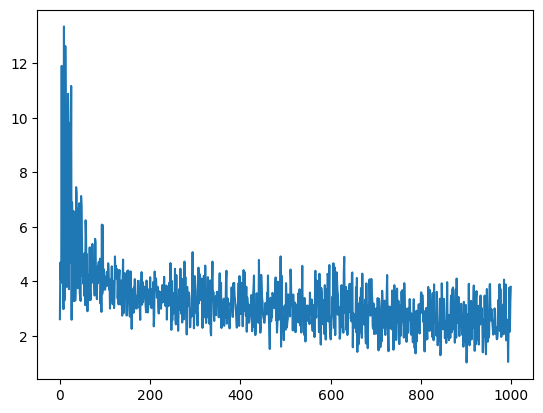

In [30]:
Ada = Neurons.AdalineMBGD(eta=0.000_000_1, n_epochs=1000)
Ada.fit(X_train, Y_train)

print("Weights: ", Ada.w_)

Y_pred = Ada.predict(X_test)
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(Ada.cost_)

Weights:  [-0.0629014  -3.32276551 -1.34589845  3.04320637  4.41989538  9.86782817
 -2.24556698 -6.88610045  8.51926777  1.47093377  4.71413712 -0.28590396
  3.23712552  2.13543628 -1.37104688  1.80073507  0.22831681]
Error rate:  0.08333333333333333


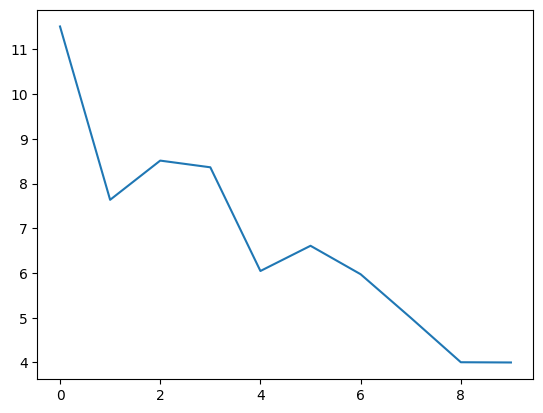

In [31]:
Y_t = np.where(Y_train == -1, 0, 1)

PM = Neurons.PerceptronMcKay(eta=0.01, n_epochs=10)
PM.fit(X_train, Y_t)

print("Weights: ", PM.w_)


Y_pred = [np.where(PM.predict(xi) >= .5, 1, -1) for xi in X_test]
error_rate = np.sum(Y_test != Y_pred) / Y_test.shape[0]
print("Error rate: ", error_rate)

plt.plot(PM.errors_)